# Week 2: Hidden Anomalies in Observed Data

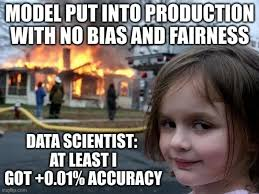

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("data")  # TODO: change if necessary

# In Colab you may instead upload the CSVs:
# from google.colab import files
# files.upload()

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [3]:
## TODO: implement a reusable dataset summary.
#def dataset_summary(df, label=None):
#    raise NotImplementedError

## TODO: compare train, validation, and test feature distributions.
# Include categorical as well as numeric variables.

def dataset_summary(df, label=None):
    print(f"--- {label or 'dataset'} ---")
    print("Shape:", df.shape)

    print("\nMissing values per column:")
    print(df.isna().sum()[df.isna().sum() > 0])

    print("\nDuplicate rows:", df.duplicated().sum())
    if "row_id" in df.columns:
        print("Duplicate row_ids:", df["row_id"].duplicated().sum())

    numeric_cols = df.select_dtypes(include="number").columns
    print("\nNumeric column ranges (check for impossible values):")
    print(df[numeric_cols].agg(["min", "max"]).T)

    categorical_cols = df.select_dtypes(include="object").columns
    print("\nCategorical column value counts:")
    for col in categorical_cols:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))

    if label is not None and label in df.columns:
        print(f"\nTarget prevalence ({label}):")
        print(df[label].value_counts(normalize=True))

    return None

dataset_summary(train, label="income_observed")
dataset_summary(validation, label="income_observed")
dataset_summary(test_features, label="income_observed")

--- income_observed ---
Shape: (18000, 15)

Missing values per column:
Series([], dtype: int64)

Duplicate rows: 0
Duplicate row_ids: 0

Numeric column ranges (check for impossible values):
                  min      max
row_id            0.0  17999.0
AGEP             17.0     92.0
COW               1.0      8.0
SCHL              1.0     24.0
MAR               1.0      5.0
OCCP             10.0   9830.0
POBP              1.0    554.0
RELP              0.0     17.0
WKHP              1.0     99.0
SEX               1.0      2.0
RAC1P             1.0      9.0
income_observed   0.0      1.0

Categorical column value counts:

SEX_group:
SEX_group
Male      9565
Female    8435
Name: count, dtype: int64

RACE_group:
RACE_group
White                   14021
Black                    1644
Asian                     924
Other race                895
Two or more races         396
American Indian            75
AIAN specified/other       33
Pacific Islander           10
Alaska Native               2
N

/var/folders/2q/fq4zt8r176583r4v4jy_hxgh0000gn/T/ipykernel_75599/3473811289.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns
/var/folders/2q/fq4zt8r176583r4v4jy_hxgh0000gn/T/ipykernel_75599/3473811289.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See htt

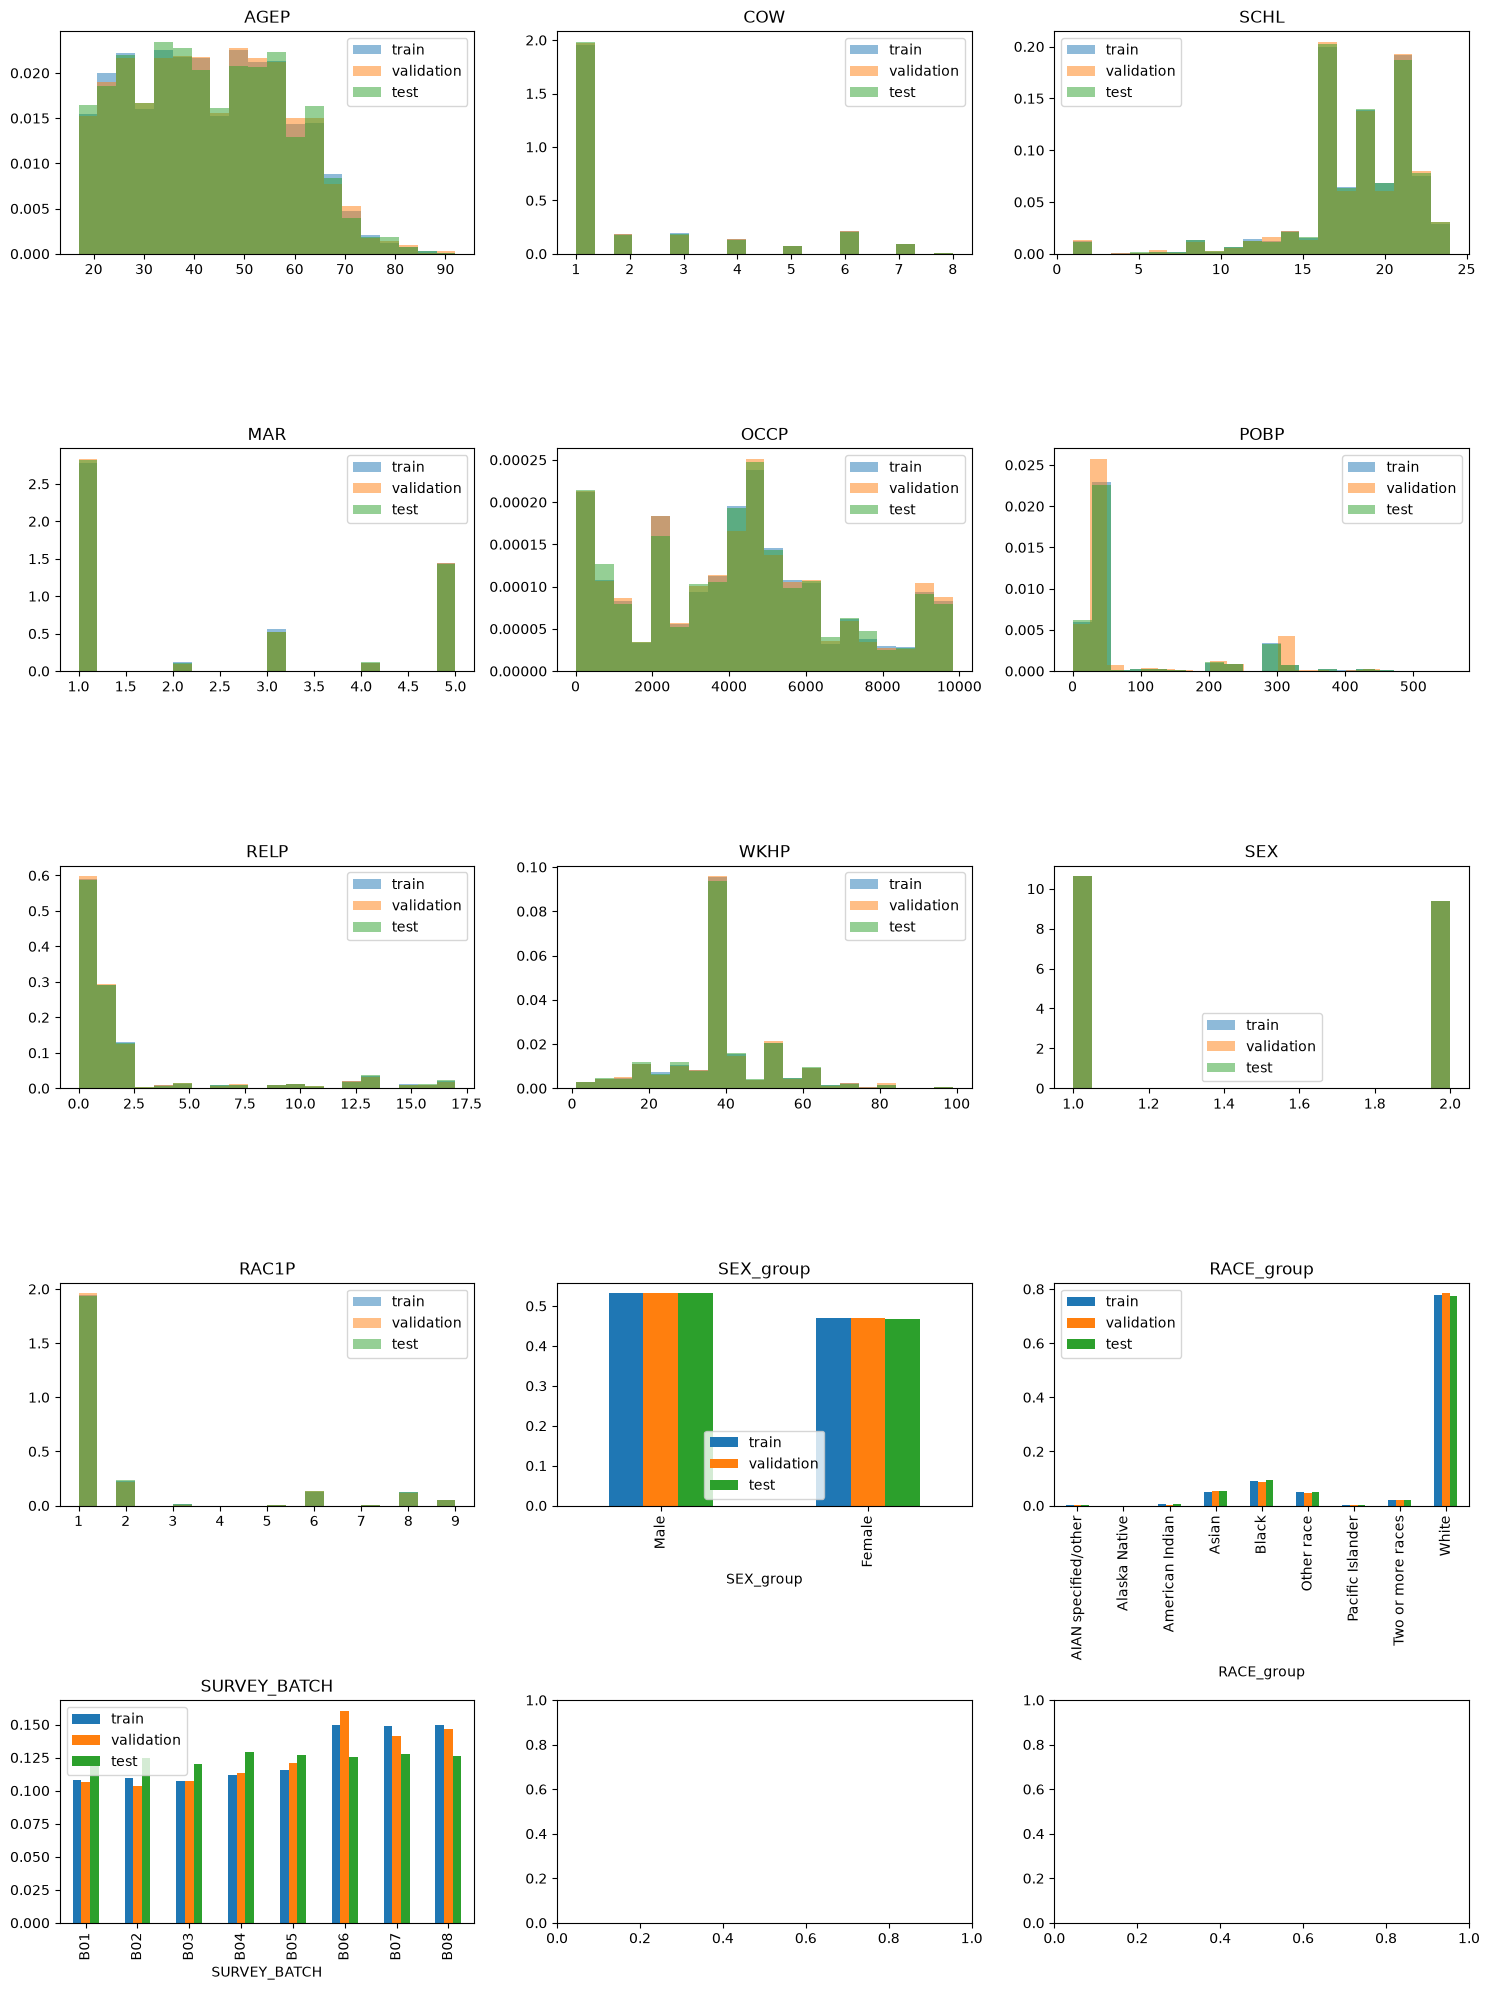

In [4]:
def compare_distributions(train, validation, test_features):
    datasets = {"train": train, "validation": validation, "test": test_features}
    columns = [c for c in train.columns if c not in ["row_id", "income_observed"]]

    n_cols = 3
    n_rows = -(-len(columns) // n_cols)  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        if pd.api.types.is_numeric_dtype(train[col]):
            for name, df in datasets.items():
                ax.hist(df[col].dropna(), bins=20, alpha=0.5, density=True, label=name)
        else:
            props = pd.DataFrame({
                name: df[col].value_counts(normalize=True) for name, df in datasets.items()
            })
            props.plot(kind="bar", ax=ax, legend=False)

        ax.set_title(col)
        ax.legend()

    plt.tight_layout()
    plt.show()

compare_distributions(train, validation, test_features)


Biased towards people in the private sector - white maried men.
Der er ikke nødvendigvis fordelingsmæssig forskel osv. 

Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

## TODO: choose features and justify exclusions.
#FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]

NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
# TODO: write a model factory that handles numeric and categorical columns.
#def make_model(frame):
#    raise NotImplementedError

def make_model(frame):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
    return Pipeline([
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ])


# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.

model = make_model(train)
model.fit(train[FEATURE_COLUMNS], train[LABEL])

val_pred = model.predict(validation[FEATURE_COLUMNS])
val_proba = model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]

print("Accuracy:", accuracy_score(validation[LABEL], val_pred))
print("Balanced accuracy:", balanced_accuracy_score(validation[LABEL], val_pred))
print("ROC AUC:", roc_auc_score(validation[LABEL], val_proba))
print("Log loss:", log_loss(validation[LABEL], val_proba))
print("Brier score:", brier_score_loss(validation[LABEL], val_proba))


Accuracy: 0.7861666666666667
Balanced accuracy: 0.7455913431463247
ROC AUC: 0.8485252180364264
Log loss: 0.4486714200210925
Brier score: 0.14629042412527818


In [6]:
from sklearn.ensemble import RandomForestClassifier

def make_rf_model(frame):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
    return Pipeline([
        ("preprocess", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ])

rf_model = make_rf_model(train)
rf_model.fit(train[FEATURE_COLUMNS], train[LABEL])

rf_val_pred = rf_model.predict(validation[FEATURE_COLUMNS])
rf_val_proba = rf_model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]

print("Accuracy:", accuracy_score(validation[LABEL], rf_val_pred))
print("Balanced accuracy:", balanced_accuracy_score(validation[LABEL], rf_val_pred))
print("ROC AUC:", roc_auc_score(validation[LABEL], rf_val_proba))
print("Log loss:", log_loss(validation[LABEL], rf_val_proba))
print("Brier score:", brier_score_loss(validation[LABEL], rf_val_proba))


Accuracy: 0.773
Balanced accuracy: 0.7237913200808191
ROC AUC: 0.834518477616724
Log loss: 0.49385349827779546
Brier score: 0.1531479066505102


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [8]:
from fairlearn.metrics import MetricFrame, selection_rate, count
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# TODO: implement robust metric functions.
# TODO: construct MetricFrame for SEX_group and at least one intersection.

In [9]:
import numpy as np

def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def safe_log_loss(y_true, y_score):
    return log_loss(y_true, y_score, labels=[0, 1])



LABEL_METRICS = {
    "count": count,
    "selection_rate": selection_rate,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
    "ppv": positive_predictive_value,
    "npv": negative_predictive_value,
}

PROBA_METRICS = {
    "log_loss": safe_log_loss,
    "brier_score": brier_score_loss,
    "roc_auc": safe_roc_auc,
}

def fairness_report(y_true, y_pred, y_proba, sensitive_df, title=""):
    label_mf = MetricFrame(metrics=LABEL_METRICS, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_df)
    proba_mf = MetricFrame(metrics=PROBA_METRICS, y_true=y_true, y_pred=y_proba, sensitive_features=sensitive_df)

    by_group = label_mf.by_group.join(proba_mf.by_group).round(3)
    overall = pd.concat([label_mf.overall, proba_mf.overall]).round(3).to_frame("value")
    gaps = label_mf.difference(method="between_groups")[["tpr", "fpr"]].round(3).to_frame("gap")

    print(f"\n===== {title} =====")
    print("\nBy group:")
    display(by_group)
    print("\nOverall:")
    display(overall)
    print("\nEqualized-odds gaps (max - min across groups):")
    display(gaps)

    # bar chart of all metrics (except count, which is on a different scale)
    plot_cols = [c for c in by_group.columns if c != "count"]
    ax = by_group[plot_cols].plot(kind="bar", figsize=(10, 4), title=f"{title} — metrics by group")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, rotation=90, padding=2)
    ax.set_ylabel("value")
    ax.set_ylim(0, np.nanmax(by_group[plot_cols].values) * 1.25)  # headroom for labels
    plt.xticks(rotation=45, ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return label_mf, proba_mf



===== Logistic Regression — SEX_group =====

By group:


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv,log_loss,brier_score,roc_auc
SEX_group,,,,,,,,,,,
Female,2812.0,0.217,0.791,0.692,0.516,0.131,0.529,0.863,0.430,0.140,0.810
Male,3188.0,0.366,0.782,0.769,0.671,0.133,0.795,0.775,0.465,0.152,0.863



Overall:


,value
count,6000.000
selection_rate,0.296
accuracy,0.786
balanced_accuracy,0.746
tpr,0.623
fpr,0.132
ppv,0.703
npv,0.821
log_loss,0.449
brier_score,0.146



Equalized-odds gaps (max - min across groups):


,gap
tpr,0.155
fpr,0.002


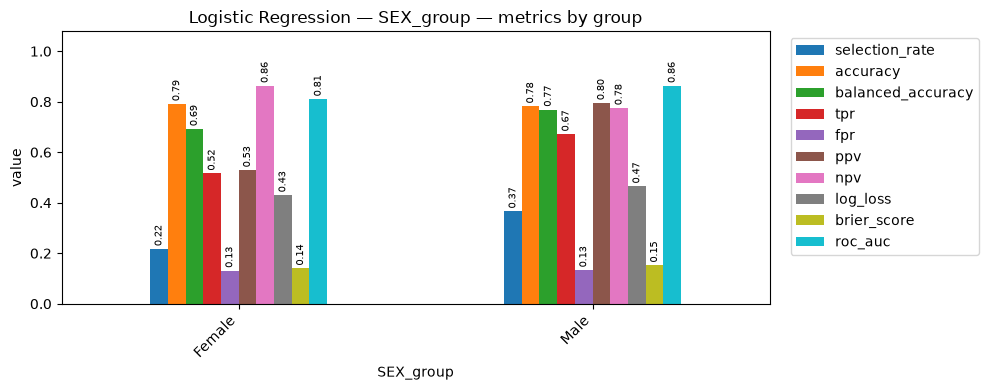

/Users/KAROLINE/opt/miniconda3/envs/RAI/lib/python3.13/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



===== Logistic Regression — SEX_group x RACE_group =====

By group:


count  selection_rate  accuracy  \
SEX_group RACE_group                                               
Female    AIAN specified/other     6.0           0.167     1.000   
          American Indian          9.0           0.111     0.778   
          Asian                  153.0           0.320     0.752   
          Black                  285.0           0.123     0.825   
          Other race             116.0           0.112     0.845   
          Pacific Islander         2.0           0.000     0.500   
          Two or more races       55.0           0.236     0.709   
          White                 2186.0           0.227     0.788   
Male      AIAN specified/other     9.0           0.111     1.000   
          American Indian         11.0           0.364     0.909   
          Asian                  165.0           0.485     0.794   
          Black                  241.0           0.203     0.726   
          Other race             165.0           0.091     0.855   
          Pacific Islander         1.0           0.000     1.000   
          Two or more races       79.0           0.266     0.785   
          White                 2517.0           0.397     0.781   

                                balanced_accuracy    tpr    fpr    ppv    npv  \
SEX_group RACE_group                                                            
Female    AIAN specified/other              1.000  1.000  0.000  1.000  1.000   
          American Indian                   0.438  0.000  0.125  0.000  0.875   
          Asian                             0.717  0.649  0.216  0.490  0.875   
          Black                             0.635  0.347  0.076  0.486  0.872   
          Other race                        0.610  0.308  0.087  0.308  0.913   
          Pacific Islander                  0.500  0.000  0.000  0.000  0.500   
          Two or more races                 0.580  0.364  0.205  0.308  0.833   
          White                             0.699  0.532  0.134  0.547  0.858   
Male      AIAN specified/other              1.000  1.000  0.000  1.000  1.000   
          American Indian                   0.938  1.000  0.125  0.750  1.000   
          Asian                             0.794  0.788  0.200  0.788  0.800   
          Black                             0.633  0.387  0.120  0.592  0.760   
          Other race                        0.654  0.345  0.037  0.667  0.873   
          Pacific Islander                  1.000  0.000  0.000  0.000  1.000   
          Two or more races                 0.737  0.571  0.098  0.762  0.793   
          White                             0.775  0.691  0.142  0.808  0.763   

                                log_loss  brier_score  roc_auc  
SEX_group RACE_group                                            
Female    AIAN specified/other     0.169        0.042    1.000  
          American Indian          0.539        0.180    0.500  
          Asian                    0.496        0.163    0.789  
          Black                    0.408        0.127    0.759  
          Other race               0.309        0.098    0.802  
          Pacific Islander         0.428        0.156    1.000  
          Two or more races        0.432        0.148    0.793  
          White                    0.435        0.142    0.815  
Male      AIAN specified/other     0.148        0.035    1.000  
          American Indian          0.372        0.106    1.000  
          Asian                    0.450        0.145    0.873  
          Black                    0.510        0.169    0.794  
          Other race               0.369        0.115    0.809  
          Pacific Islander         0.102        0.009      NaN  
          Two or more races        0.476        0.152    0.845  
          White                    0.470        0.154    0.864


Overall:


,value
count,6000.000
selection_rate,0.296
accuracy,0.786
balanced_accuracy,0.746
tpr,0.623
fpr,0.132
ppv,0.703
npv,0.821
log_loss,0.449
brier_score,0.146



Equalized-odds gaps (max - min across groups):


,gap
tpr,1.000
fpr,0.216


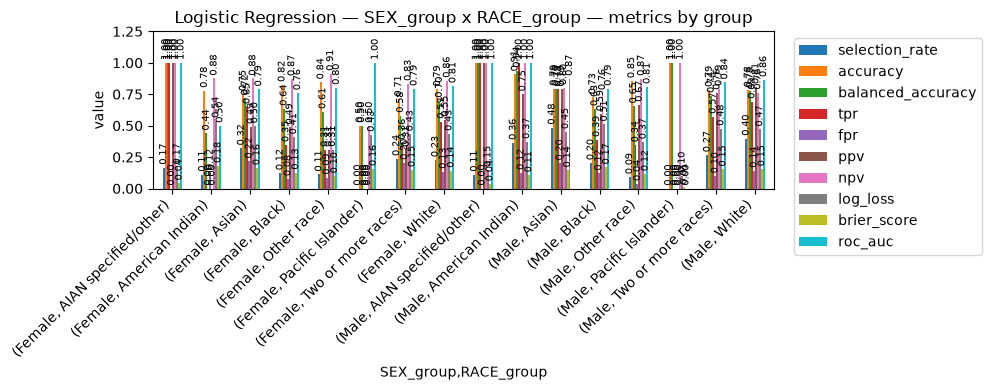

(<fairlearn.metrics._metric_frame.MetricFrame at 0x12245d1d0>,
 <fairlearn.metrics._metric_frame.MetricFrame at 0x1225175c0>)

In [10]:
# SEX_group only
fairness_report(validation[LABEL], val_pred, val_proba, validation[SENSITIVE], title="Logistic Regression — SEX_group")


# Intersection of SEX_group and RACE_group
fairness_report(validation[LABEL], val_pred, val_proba, validation[["SEX_group", "RACE_group"]], title="Logistic Regression — SEX_group x RACE_group")


### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

In [ ]:
# TODO: implement calibration tables, reliability plots, and a numerical summary such as ECE.
# State how you handle small bins and why your binning choice is defensible.

# TODO: Mitigation

In [11]:
def calibration_table(y_true, y_proba, n_bins=10, min_bin_size=30):
    data = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    data["bin"] = pd.qcut(data["y_proba"], q=n_bins, duplicates="drop")

    table = data.groupby("bin", observed=True).agg(
        mean_predicted=("y_proba", "mean"),
        observed_rate=("y_true", "mean"),
        count=("y_true", "size"),
    ).reset_index()

    table["gap"] = (table["mean_predicted"] - table["observed_rate"]).abs()
    table["reliable"] = table["count"] >= min_bin_size
    return table

def expected_calibration_error(table):
    total = table["count"].sum()
    return float((table["count"] / total * table["gap"]).sum())


In [12]:
def reliability_plot(y_true, y_proba, group=None, n_bins=10, title=""):
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")

    groups = {"all": pd.Series(True, index=y_true.index)} if group is None else {
        g: (group == g) for g in sorted(group.unique())
    }

    for name, mask in groups.items():
        table = calibration_table(y_true[mask], y_proba[mask], n_bins=n_bins)
        plt.plot(table["mean_predicted"], table["observed_rate"], marker="o", label=name)
        ece = expected_calibration_error(table)
        brier = brier_score_loss(y_true[mask], y_proba[mask])
        print(f"{name}: ECE={ece:.3f}, Brier={brier:.3f}, n={mask.sum()}")

    plt.xlabel("Mean predicted probability")
    plt.ylabel(f"Observed frequency of {LABEL} = 1")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


,bin,mean_predicted,observed_rate,count,gap,reliable
0,"(-0.000317, 0.0215]",0.010428,0.016667,600,0.006238,True
1,"(0.0215, 0.0562]",0.037282,0.048333,600,0.011051,True
2,"(0.0562, 0.104]",0.078838,0.083333,600,0.004495,True
3,"(0.104, 0.175]",0.138383,0.136667,600,0.001716,True
4,"(0.175, 0.265]",0.219593,0.231667,600,0.012073,True
5,"(0.265, 0.379]",0.319735,0.301667,600,0.018068,True
6,"(0.379, 0.496]",0.436614,0.425000,600,0.011614,True
7,"(0.496, 0.626]",0.560624,0.541667,600,0.018957,True
8,"(0.626, 0.762]",0.690235,0.691667,600,0.001432,True
9,"(0.762, 0.992]",0.846689,0.866667,600,0.019978,True


ECE: 0.0105624117391892
Female: ECE=0.061, Brier=0.140, n=2812
Male: ECE=0.051, Brier=0.152, n=3188


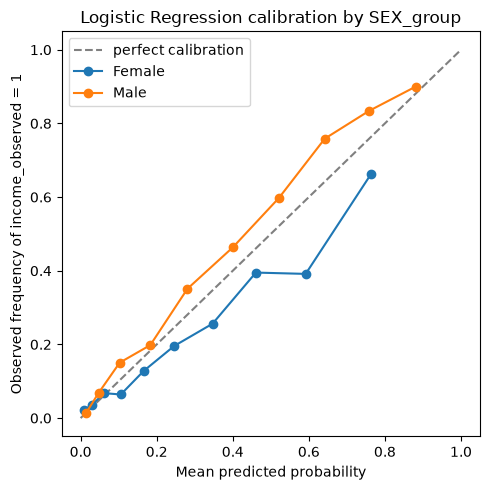

In [13]:
# overall calibration table + ECE
table = calibration_table(validation[LABEL], val_proba)
display(table)
print("ECE:", expected_calibration_error(table))

# reliability curve split by SEX_group
reliability_plot(validation[LABEL], val_proba, group=validation["SEX_group"], title="Logistic Regression calibration by SEX_group")


Breaking down what each number tells you:

ECE (Expected Calibration Error) — averages how far the predicted probabilities are from the actual observed rates, weighted by how many points fall in each bin. Lower = better calibrated.

Overall ECE = 0.011 — looks great, essentially well-calibrated.
Female ECE = 0.061, Male ECE = 0.051 — both are 5–6x higher than the overall number.
This is the important finding: the overall ECE is misleadingly good because it averages over both groups, and their miscalibration partly cancels out (Female's curve bows one way, Male's roughly follows the diagonal, so pooling them hides the Female group's problem). This is exactly why the notebook's hint told you to check calibration by group — the aggregate metric alone would have told you "everything is fine," which isn't true for women in this dataset.

Brier score — this is a different beast: it measures overall probabilistic accuracy (calibration and how sharply/confidently the model discriminates between classes), not calibration alone.

Female Brier = 0.140 (lower/better) vs Male Brier = 0.152 (higher/worse) — despite Male being better calibrated (lower ECE).
That's not a contradiction — it means the model is more decisive/confident for Female predictions (making sharper, more spread-out probability predictions), just calibrated less accurately; while for Male it's better calibrated but perhaps less sharp/more "hedged" in its probabilities. Brier score rewards both good calibration and confident correct predictions, so a model can trade one for the other.

Bottom line for your audit: overall metrics hid a real subgroup calibration gap — worth listing as observed evidence, separate from any hypothesis about why (data quality issue vs. genuine distribution shift vs. model limitation).

Before mitigation  |  TPR gap: 0.155, FPR gap: 0.002


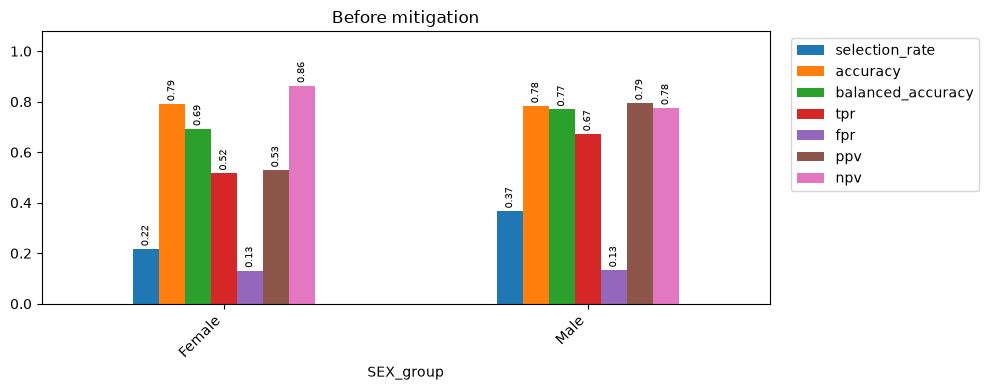

After mitigation (equalized odds)  |  TPR gap: 0.011, FPR gap: 0.006


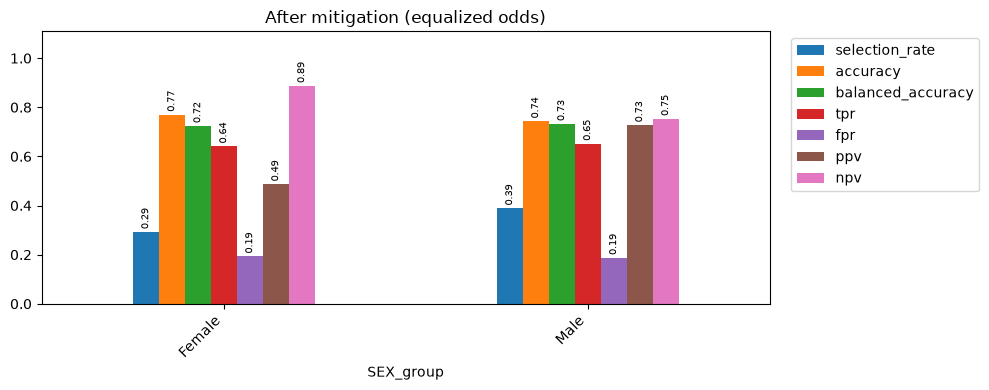

In [15]:
from fairlearn.postprocessing import ThresholdOptimizer

mitigator = ThresholdOptimizer(
    estimator=model,              # your already-fitted logistic regression pipeline
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)
mitigator.fit(train[FEATURE_COLUMNS], train[LABEL], sensitive_features=train[SENSITIVE])

mitigated_pred = mitigator.predict(
    validation[FEATURE_COLUMNS],
    sensitive_features=validation[SENSITIVE],
    random_state=RANDOM_STATE,
)

def fairness_report_labels_only(y_true, y_pred, sensitive_df, title=""):
    mf = MetricFrame(metrics=LABEL_METRICS, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_df)

    gaps = mf.difference(method="between_groups")
    print(f"{title}  |  TPR gap: {gaps['tpr']:.3f}, FPR gap: {gaps['fpr']:.3f}")

    plot_cols = [c for c in mf.by_group.columns if c != "count"]
    ax = mf.by_group[plot_cols].plot(kind="bar", figsize=(10, 4), title=title)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, rotation=90, padding=2)
    ax.set_ylim(0, np.nanmax(mf.by_group[plot_cols].values) * 1.25)
    plt.xticks(rotation=45, ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return mf


fairness_report_labels_only(validation[LABEL], val_pred, validation[SENSITIVE], title="Before mitigation")
fairness_report_labels_only(validation[LABEL], mitigated_pred, validation[SENSITIVE], title="After mitigation (equalized odds)")


In [17]:
def hard_prediction_calibration_plot(y_true, y_pred, group, title=""):
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")

    for g in sorted(group.unique()):
        mask = group == g
        observed_by_pred = pd.DataFrame({"y_true": y_true[mask], "y_pred": y_pred[mask]}).groupby("y_pred")["y_true"].mean()
        plt.plot(observed_by_pred.index, observed_by_pred.values, marker="o", linestyle="-", label=g)

    plt.xlabel("Predicted class (0 or 1)")
    plt.ylabel(f"Observed frequency of {LABEL} = 1")
    plt.xlim(-0.1, 1.1)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


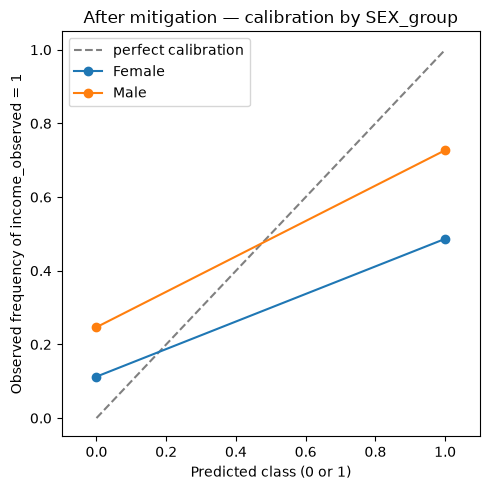

In [18]:
hard_prediction_calibration_plot(validation[LABEL], mitigated_pred, validation["SEX_group"], title="After mitigation — calibration by SEX_group")


ThresholdOptimizer (unlike your logistic regression / random forest) doesn't output a continuous probability — it just outputs a hard 0/1 decision per person (it works by picking a cutoff, or randomly flipping between two cutoffs, per group). So a "calibration curve" for it can't have the smooth 10-point shape you saw before — it collapses to two points: "of everyone predicted 0, what fraction actually had income_observed = 1?" and same for predicted 1. That's really just visualizing NPV/PPV, but it's still the right way to check whether the mitigated model at least agrees with reality similarly across groups.


It'll naturally produce only 2 dots per group (since mitigated_pred only takes values 0 and 1), rather than 10 — which is expected and correct here, not a bug.

Week 2 is supposed to be bad because we are evaluating on biased labels.

## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

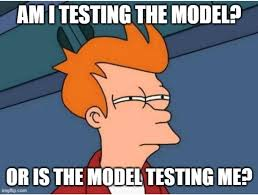

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
